# Taller — Gestión Avanzada de Portafolios
## Análisis estadístico de dos activos: QQQ y CCJ

**Maestría en Administración Financiera · Universidad EAFIT**

**Integrantes:**
- David Adrián Armendáriz Peña
- Ana Sofía Nanclares Rúa
- Angie Catalina Restrepo Cardona
- Edwin Andrés Durán León

**Enunciado.** Escoger 2 activos y, con información diaria para los últimos 5 años, responder:

1. Calcular retorno aritmético y geométrico.
2. Calcular desviación estándar de cada activo y calcular el rango de retornos al 95% de confianza.
3. Calcular los percentiles 2.5% y 97.5%. Interpretar las diferencias con el punto 2.
4. Calcular coeficiente de correlación entre los 2 activos. Interpretar el resultado.
5. ¿Cuál de los 2 activos elegiría para invertir, o qué combinación de los 2 activos, y por qué?

**Activos escogidos**

| Ticker | Nombre | Naturaleza |
|---|---|---|
| **QQQ** | Invesco QQQ Trust | ETF que replica el índice Nasdaq-100: cartera diversificada de ~100 empresas no financieras más grandes del Nasdaq, con fuerte peso tecnológico (Apple, Microsoft, Nvidia, Amazon, Broadcom, Meta...). Beta de mercado, diversificado. |
| **CCJ** | Cameco Corporation | Mayor productor mundial de uranio (combustible nuclear), que cotiza en NYSE/TSX desde los años 90. Acción individual, cíclica y concentrada en un solo commodity/sector, con narrativa reciente ligada al resurgimiento de la energía nuclear y a la demanda de electricidad de centros de datos de IA. |

Se eligen deliberadamente dos activos de **naturaleza opuesta** — un ETF ampliamente diversificado frente a una acción individual concentrada en un commodity — para que las preguntas de correlación y combinación de portafolio (puntos 4 y 5) tengan contenido económico real.

**Ventana de datos.** Ambos activos tienen historial diario largo (CCJ cotiza desde 1996, QQQ desde 1999), por lo que se usan los **5 años exactos** de información diaria que pide el enunciado: del 20 de septiembre de 2021 al 18 de septiembre de 2026 (1,255 precios de cierre, 1,254 retornos diarios por activo).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from scipy import stats
import yfinance as yf

plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

TICKERS = ["QQQ", "CCJ"]
START = "2021-09-19"   # ventana de 5 años calendario hasta hoy
END = "2026-09-19"     # exclusivo; último día de mercado incluido: 2026-09-18
TRADING_DAYS = 252     # días bursátiles por año, estándar de mercado
RF_ANNUAL = 0.04       # tasa libre de riesgo anual de referencia (T-bill 3M aprox.), usada solo en el punto 5

precios = yf.download(TICKERS, start=START, end=END, auto_adjust=True, progress=False)["Close"]
precios = precios[TICKERS].dropna()
print(f"Observaciones de precio: {len(precios)}  |  {precios.index.min().date()} -> {precios.index.max().date()}")
precios.tail()

Observaciones de precio: 1255  |  2021-09-20 -> 2026-09-18


Ticker,QQQ,CCJ
Date,,
2026-09-14,709.179993,93.260002
2026-09-15,704.539978,91.209999
2026-09-16,704.719971,90.900002
2026-09-17,716.919983,92.800003
2026-09-18,721.450012,91.620003


Se descargan precios de cierre **ajustados** (`auto_adjust=True`: incorpora dividendos y *splits*), que es la serie correcta para calcular retornos de un inversionista que mantiene el activo.

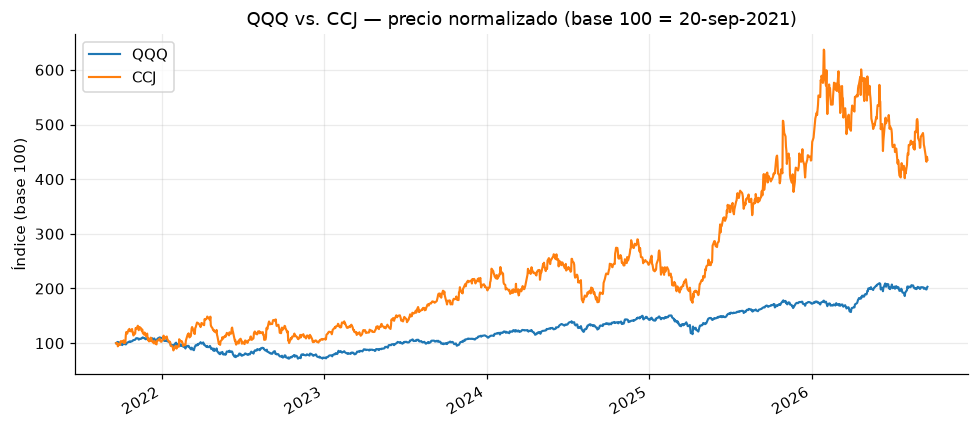

In [2]:
fig, ax = plt.subplots(figsize=(9, 4))
(precios / precios.iloc[0] * 100).plot(ax=ax, lw=1.4)
ax.set_title("QQQ vs. CCJ — precio normalizado (base 100 = 20-sep-2021)")
ax.set_ylabel("Índice (base 100)")
ax.set_xlabel("")
ax.legend(title=None)
plt.tight_layout()
plt.show()

In [3]:
retornos = precios.pct_change().dropna()
n = len(retornos)
print(f"Retornos diarios simples: {n} observaciones por activo")
retornos.describe()

Retornos diarios simples: 1254 observaciones por activo


Ticker,QQQ,CCJ
count,1254.000000,1254.000000
mean,0.000670,0.001659
std,0.014482,0.031310
min,-0.062109,-0.151607
25%,-0.007038,-0.016574
50%,0.001047,0.000568
75%,0.008735,0.018410
max,0.120031,0.234242


El retorno diario simple del día $t$ para un activo se define como

$$r_t = \frac{P_t}{P_{t-1}} - 1$$

donde $P_t$ es el precio de cierre ajustado en $t$. Todos los cálculos que siguen se hacen sobre esta serie $\{r_t\}_{t=1}^{n}$, con $n = 1{,}254$ retornos diarios por activo.

## 1. Retorno aritmético y retorno geométrico

**Retorno aritmético (media simple).** Es el promedio no ponderado de los retornos diarios:

$$\bar r_{arit} = \frac{1}{n}\sum_{t=1}^{n} r_t$$

Responde a la pregunta "¿cuál fue el retorno promedio de un día cualquiera?". Es el estimador correcto del retorno **esperado de un solo período**, pero **sobreestima** el crecimiento acumulado de una inversión mantenida varios períodos porque ignora el efecto de la capitalización compuesta.

**Retorno geométrico (media geométrica).** Es el retorno constante por período que replica el crecimiento efectivamente observado:

$$\bar r_{geo} = \left(\prod_{t=1}^{n}(1+r_t)\right)^{1/n} - 1 = \left(\frac{P_n}{P_0}\right)^{1/n} - 1$$

Es el retorno relevante para medir el desempeño **histórico realizado** de una inversión buy-and-hold, y siempre cumple $\bar r_{geo} \le \bar r_{arit}$ (igualdad solo si la varianza de los retornos es cero). La brecha entre ambos —el llamado *variance drag* o *volatility drag*— es aproximadamente

$$\bar r_{arit} - \bar r_{geo} \approx \frac{\sigma^2}{2}$$

es decir, **crece con la volatilidad del activo**: penaliza más a los activos más volátiles.

Ambas medidas se anualizan de forma distinta porque una es aditiva y la otra es multiplicativa:

$$\bar r_{arit}^{\,anual} = \bar r_{arit} \times 252 \qquad\qquad \bar r_{geo}^{\,anual} = (1+\bar r_{geo})^{252} - 1$$

In [4]:
tabla1 = pd.DataFrame(index=TICKERS)
for t in TICKERS:
    r = retornos[t]
    arit_d = r.mean()
    geo_d = (1 + r).prod() ** (1 / n) - 1
    tabla1.loc[t, "Aritmético diario"] = arit_d
    tabla1.loc[t, "Geométrico diario"] = geo_d
    tabla1.loc[t, "Aritmético anual"] = arit_d * TRADING_DAYS
    tabla1.loc[t, "Geométrico anual"] = (1 + geo_d) ** TRADING_DAYS - 1
    tabla1.loc[t, "Brecha anual (arit - geo)"] = tabla1.loc[t, "Aritmético anual"] - tabla1.loc[t, "Geométrico anual"]

tabla1_fmt = tabla1.copy()
for c in tabla1_fmt.columns:
    tabla1_fmt[c] = tabla1_fmt[c].map(lambda x: f"{x:.4%}")
tabla1_fmt

,Aritmético diario,Geométrico diario,Aritmético anual,Geométrico anual,Brecha anual (arit - geo)
QQQ,0.0670%,0.0565%,16.8736%,15.2965%,1.5771%
CCJ,0.1659%,0.1174%,41.8157%,34.3888%,7.4269%


**Verificación cruzada del retorno geométrico anual**: equivale al CAGR (*Compound Annual Growth Rate*) del período, $(P_{fin}/P_{ini})^{1/T_{años}} - 1$, con $T_{años} = n/252$.

In [5]:
anios = n / TRADING_DAYS
for t in TICKERS:
    cagr = (precios[t].iloc[-1] / precios[t].iloc[0]) ** (1 / anios) - 1
    print(f"{t}: CAGR directo sobre precios = {cagr:.4%}  |  geométrico anualizado desde retornos diarios = {tabla1.loc[t,'Geométrico anual']:.4%}")

QQQ: CAGR directo sobre precios = 15.2965%  |  geométrico anualizado desde retornos diarios = 15.2965%
CCJ: CAGR directo sobre precios = 34.3888%  |  geométrico anualizado desde retornos diarios = 34.3888%


**Interpretación.** CCJ tiene un retorno geométrico anualizado muy superior al de QQQ (~34% vs. ~15%) durante estos 5 años, impulsado por el resurgimiento del interés en energía nuclear y la escasez estructural de uranio. En ambos activos el retorno geométrico es menor al aritmético, como exige la teoría, pero **la brecha es mucho mayor en CCJ** (~7.4 p.p. anuales, activo individual y más volátil) que en QQQ (~1.6 p.p., ETF diversificado): la alta volatilidad de CCJ "cuesta" más en términos de crecimiento compuesto efectivo. Comparar solo el retorno aritmético habría exagerado aún más la ventaja de CCJ frente a QQQ; el geométrico es la medida correcta para evaluar el desempeño histórico realizado.

## 2. Desviación estándar y rango de retornos al 95% de confianza

La **desviación estándar muestral** de los retornos diarios mide la dispersión (volatilidad) alrededor de la media:

$$\sigma = \sqrt{\frac{1}{n-1}\sum_{t=1}^n (r_t - \bar r_{arit})^2}$$

Se anualiza escalando por $\sqrt{252}$ (bajo el supuesto de retornos diarios independientes e idénticamente distribuidos, la varianza escala linealmente con el número de períodos y la desviación estándar con su raíz cuadrada):

$$\sigma^{anual} = \sigma \times \sqrt{252}$$

**Rango de retornos al 95% de confianza.** Asumiendo que los retornos siguen (aproximadamente) una distribución **normal** $r \sim N(\bar r_{arit}, \sigma^2)$, el intervalo que contiene el 95% de la probabilidad se construye con el valor crítico $z_{0.975} = 1.96$ de la normal estándar:

$$IC_{95\%} = \bar r_{arit} \pm 1.96\,\sigma$$

Este es un rango **paramétrico**: se deriva de dos únicos parámetros ($\bar r$, $\sigma$) y del supuesto de normalidad, no directamente de la forma real de los datos.

In [6]:
tabla2 = pd.DataFrame(index=TICKERS)
Z95 = 1.96
for t in TICKERS:
    r = retornos[t]
    mu_d, sd_d = r.mean(), r.std(ddof=1)
    mu_a, sd_a = mu_d * TRADING_DAYS, sd_d * np.sqrt(TRADING_DAYS)
    tabla2.loc[t, "Desv. est. diaria"] = sd_d
    tabla2.loc[t, "Desv. est. anual"] = sd_a
    tabla2.loc[t, "IC95% diario - inf"] = mu_d - Z95 * sd_d
    tabla2.loc[t, "IC95% diario - sup"] = mu_d + Z95 * sd_d
    tabla2.loc[t, "IC95% anual - inf"] = mu_a - Z95 * sd_a
    tabla2.loc[t, "IC95% anual - sup"] = mu_a + Z95 * sd_a

tabla2_fmt = tabla2.copy()
for c in tabla2_fmt.columns:
    tabla2_fmt[c] = tabla2_fmt[c].map(lambda x: f"{x:.4%}")
tabla2_fmt

,Desv. est. diaria,Desv. est. anual,IC95% diario - inf,IC95% diario - sup,IC95% anual - inf,IC95% anual - sup
QQQ,1.4482%,22.9889%,-2.7714%,2.9054%,-28.1846%,61.9317%
CCJ,3.1310%,49.7033%,-5.9709%,6.3027%,-55.6028%,139.2343%


**Interpretación.** La volatilidad diaria de CCJ (~3.13%) más que **duplica** la de QQQ (~1.45%), como es esperable al comparar una acción individual concentrada en un commodity frente a un ETF de 100 empresas diversificadas. Anualizada, la desviación estándar de CCJ (~50%) es también más del doble que la de QQQ (~23%). Como consecuencia, el rango normal al 95% de CCJ es mucho más ancho (aprox. −56% a +139% anual) que el de QQQ (aprox. −28% a +62% anual): el modelo normal le asigna a CCJ una probabilidad no despreciable de resultados anuales extremos en ambas direcciones.

## 3. Percentiles 2.5% y 97.5% — comparación con el punto 2

Los **percentiles empíricos** 2.5% y 97.5% se calculan directamente sobre la distribución **observada** de los retornos diarios, sin asumir ninguna forma funcional:

$$P_{2.5\%} = \text{cuantil}_{0.025}(\{r_t\}) \qquad\qquad P_{97.5\%} = \text{cuantil}_{0.975}(\{r_t\})$$

Por construcción, el 95% de los retornos históricos cae entre estos dos valores. Es el análogo **no paramétrico** del intervalo de confianza normal del punto 2: en vez de suponer $r\sim N(\bar r,\sigma^2)$, deja que los datos hablen por sí mismos, incluyendo la asimetría y las colas pesadas que de hecho tienen los retornos financieros diarios.

In [7]:
tabla3 = pd.DataFrame(index=TICKERS)
for t in TICKERS:
    r = retornos[t]
    tabla3.loc[t, "Percentil 2.5% (empírico)"] = r.quantile(0.025)
    tabla3.loc[t, "Percentil 97.5% (empírico)"] = r.quantile(0.975)
    tabla3.loc[t, "IC95% normal - inf (punto 2)"] = tabla2.loc[t, "IC95% diario - inf"]
    tabla3.loc[t, "IC95% normal - sup (punto 2)"] = tabla2.loc[t, "IC95% diario - sup"]
    tabla3.loc[t, "Asimetría (skewness)"] = stats.skew(r)
    tabla3.loc[t, "Curtosis exceso"] = stats.kurtosis(r)  # exceso sobre 3 (normal = 0)

tabla3_fmt = tabla3.copy()
for c in tabla3_fmt.columns[:4]:
    tabla3_fmt[c] = tabla3_fmt[c].map(lambda x: f"{x:.4%}")
for c in tabla3_fmt.columns[4:]:
    tabla3_fmt[c] = tabla3_fmt[c].map(lambda x: f"{x:.2f}")
tabla3_fmt

,Percentil 2.5% (empírico),Percentil 97.5% (empírico),IC95% normal - inf (punto 2),IC95% normal - sup (punto 2),Asimetría (skewness),Curtosis exceso
QQQ,-2.9716%,2.8064%,-2.7714%,2.9054%,0.18,4.83
CCJ,-5.7965%,6.9067%,-5.9709%,6.3027%,0.47,4.42


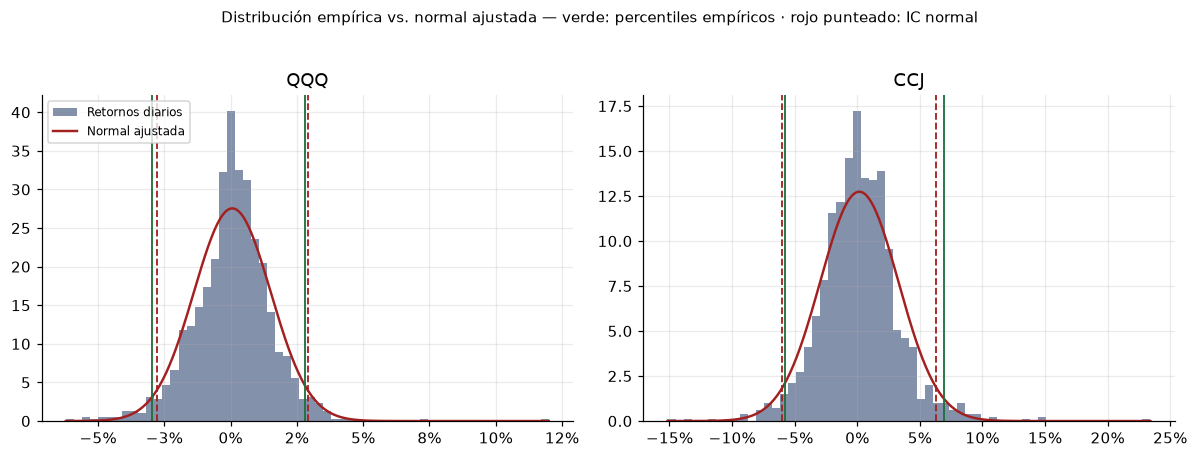

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False)
for ax, t in zip(axes, TICKERS):
    r = retornos[t]
    ax.hist(r, bins=60, density=True, alpha=0.55, color="#1f3864", label="Retornos diarios")
    x = np.linspace(r.min(), r.max(), 300)
    ax.plot(x, stats.norm.pdf(x, r.mean(), r.std(ddof=1)), color="#a32020", lw=1.6, label="Normal ajustada")
    for q, ls in [(tabla3.loc[t, "Percentil 2.5% (empírico)"], "-"), (tabla3.loc[t, "Percentil 97.5% (empírico)"], "-")]:
        ax.axvline(q, color="#1e6f3e", lw=1.2, ls=ls)
    for q in [tabla2.loc[t, "IC95% diario - inf"], tabla2.loc[t, "IC95% diario - sup"]]:
        ax.axvline(q, color="#a32020", lw=1.2, ls="--")
    ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
    ax.set_title(t)
axes[0].legend(fontsize=8, loc="upper left")
fig.suptitle("Distribución empírica vs. normal ajustada — verde: percentiles empíricos · rojo punteado: IC normal", y=1.03, fontsize=10)
plt.tight_layout()
plt.show()

**Interpretación de las diferencias con el punto 2.** En ambos activos la curtosis en exceso es positiva y considerable (QQQ ≈ 4.8, CCJ ≈ 4.4 puntos por encima de la normal), es decir, **colas más pesadas y un pico más agudo que la normal** (distribución *leptocúrtica*), y ambos tienen asimetría positiva (más pronunciada en CCJ, 0.47 vs. 0.18 de QQQ). Esto se traduce en que:

- En **CCJ** el percentil empírico superior (+6.91% diario) queda por **encima** del límite superior normal (+6.30%) — coherente con su asimetría positiva marcada —, y el mínimo diario observado (−15.2%) y el máximo (+23.4%) exceden ampliamente lo que un modelo normal consideraría "típico" al 95%: el supuesto de normalidad **subestima el riesgo real de cola** de una acción individual como CCJ.
- En **QQQ** los percentiles empíricos (−2.97% / +2.81%) son muy parecidos al rango normal (−2.77% / +2.91%), aunque la curtosis en exceso (~4.8) es en realidad la más alta de los dos activos en términos relativos: QQQ tiene colas gruesas (eventos extremos ocasionales, como caídas fuertes del Nasdaq), pero al ser un promedio de ~100 empresas su distribución diaria sigue siendo razonablemente simétrica alrededor de la media, por lo que el rango normal aproxima bien sus percentiles centrales al 95% aunque no capture del todo sus colas.
- En general: **el punto 2 asume una forma (normal) y calcula el rango a partir de solo dos parámetros; el punto 3 no asume nada y deja que el 2.5% y el 97.5% de los datos reales definan el rango.** Cuando ambos coinciden aproximadamente —como en QQQ—, el supuesto de normalidad es razonable para el cuerpo de la distribución; cuando divergen en la cola —como en CCJ— es evidencia de que medidas de riesgo basadas en normalidad (p. ej. VaR paramétrico) deberían complementarse con medidas empíricas o históricas, sobre todo en activos individuales y asimétricos.

## 4. Coeficiente de correlación entre QQQ y CCJ

El coeficiente de correlación de Pearson estandariza la covarianza entre los dos activos por sus desviaciones estándar, para obtener una medida comparable entre −1 y 1:

$$\rho_{QQQ,CCJ} = \frac{\operatorname{Cov}(r_{QQQ}, r_{CCJ})}{\sigma_{QQQ}\,\sigma_{CCJ}} = \frac{\frac{1}{n-1}\sum_{t=1}^n (r_{QQQ,t}-\bar r_{QQQ})(r_{CCJ,t}-\bar r_{CCJ})}{\sigma_{QQQ}\,\sigma_{CCJ}}$$

Covarianza diaria QQQ-CCJ:  0.000209
Correlación (Pearson) QQQ-CCJ: 0.4599


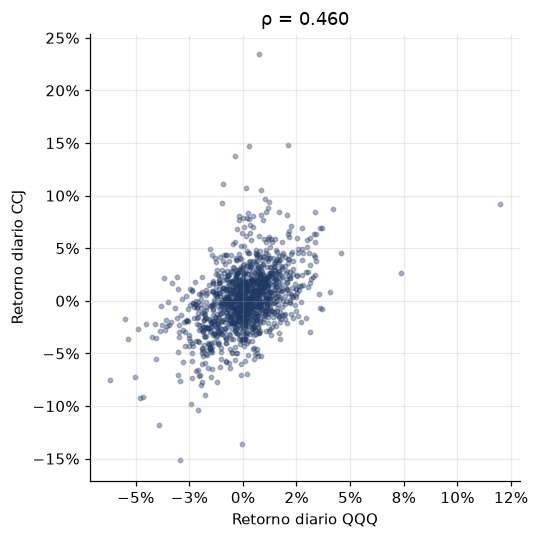

In [9]:
cov_qc = retornos["QQQ"].cov(retornos["CCJ"])
corr_qc = retornos["QQQ"].corr(retornos["CCJ"])
print(f"Covarianza diaria QQQ-CCJ:  {cov_qc:.6f}")
print(f"Correlación (Pearson) QQQ-CCJ: {corr_qc:.4f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(retornos["QQQ"], retornos["CCJ"], s=8, alpha=0.35, color="#1f3864")
ax.set_xlabel("Retorno diario QQQ")
ax.set_ylabel("Retorno diario CCJ")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title(f"ρ = {corr_qc:.3f}")
plt.tight_layout()
plt.show()

**Interpretación.** La correlación entre QQQ y CCJ es de aproximadamente **+0.46**: positiva y de magnitud **moderada**. No es sorprendente que sea positiva —ambos activos cotizan en el mismo mercado bursátil y comparten sensibilidad a factores macro comunes (tasas de interés, apetito por riesgo, ciclo económico)—, pero está lejos de +1: solo cerca de **21% de la varianza de los retornos diarios de CCJ es explicada por los movimientos de QQQ** ($R^2 = \rho^2 \approx 0.21$); el 79% restante es idiosincrática. Esa parte idiosincrática recoge la narrativa propia de CCJ (precio del uranio, contratos de suministro nuclear, política energética, geopolítica de la minería), que no está presente en un índice diversificado como QQQ. Una correlación moderada como esta es precisamente el escenario en el que combinar los dos activos en un portafolio genera **beneficio de diversificación real** (punto 5): al no moverse en lockstep, la volatilidad de la combinación puede ser menor que el promedio ponderado de las volatilidades individuales.

## 5. ¿Qué activo o combinación elegir, y por qué?

Para decidir de forma objetiva se compara el retorno esperado, el riesgo y el retorno ajustado por riesgo (**razón de Sharpe**) de cada activo por separado y de distintas combinaciones (carteras de dos activos con peso $w$ en QQQ y $(1-w)$ en CCJ):

$$r_p = w\,\mu_{QQQ} + (1-w)\,\mu_{CCJ}$$

$$\sigma_p^2 = w^2\sigma_{QQQ}^2 + (1-w)^2\sigma_{CCJ}^2 + 2w(1-w)\,\operatorname{Cov}(r_{QQQ},r_{CCJ})$$

$$\text{Sharpe} = \frac{r_p - r_f}{\sigma_p}$$

con $r_f = 4\%$ anual como referencia de tasa libre de riesgo (aprox. T-bill a 3 meses). Todas las magnitudes se anualizan como en los puntos 1 y 2.

Dos carteras de referencia tienen solución analítica cerrada para dos activos:

- **Cartera de varianza mínima**: el peso que minimiza $\sigma_p^2$ es
$$w^{*}_{min\,var} = \frac{\sigma_{CCJ}^2 - \operatorname{Cov}(r_{QQQ},r_{CCJ})}{\sigma_{QQQ}^2+\sigma_{CCJ}^2-2\operatorname{Cov}(r_{QQQ},r_{CCJ})}$$
- **Cartera tangente (máximo Sharpe)**: se obtiene resolviendo $w \propto \Sigma^{-1}(\mu - r_f\mathbf{1})$, con $\Sigma$ la matriz de covarianzas anualizada y $\mu$ el vector de retornos esperados anualizados.

In [10]:
mu_a = retornos.mean() * TRADING_DAYS
cov_a = retornos.cov() * TRADING_DAYS
var_q, var_c = cov_a.loc["QQQ", "QQQ"], cov_a.loc["CCJ", "CCJ"]
cov_qc_a = cov_a.loc["QQQ", "CCJ"]

pesos = np.linspace(0, 1, 101)
front = pd.DataFrame({"w_QQQ": pesos})
front["retorno"] = pesos * mu_a["QQQ"] + (1 - pesos) * mu_a["CCJ"]
front["riesgo"] = np.sqrt(pesos**2 * var_q + (1 - pesos) ** 2 * var_c + 2 * pesos * (1 - pesos) * cov_qc_a)
front["sharpe"] = (front["retorno"] - RF_ANNUAL) / front["riesgo"]

w_minvar = (var_c - cov_qc_a) / (var_q + var_c - 2 * cov_qc_a)
ret_minvar = w_minvar * mu_a["QQQ"] + (1 - w_minvar) * mu_a["CCJ"]
sd_minvar = np.sqrt(w_minvar**2 * var_q + (1 - w_minvar) ** 2 * var_c + 2 * w_minvar * (1 - w_minvar) * cov_qc_a)

excess = mu_a - RF_ANNUAL
inv_cov = np.linalg.inv(cov_a.values)
w_tan_raw = inv_cov @ excess.values
w_tan = w_tan_raw / w_tan_raw.sum()
w_tan_qqq = w_tan[list(mu_a.index).index("QQQ")]
ret_tan = w_tan @ mu_a.values
sd_tan = np.sqrt(w_tan @ cov_a.values @ w_tan)
sharpe_tan = (ret_tan - RF_ANNUAL) / sd_tan

resumen = pd.DataFrame({
    "Retorno anual": [mu_a["QQQ"], mu_a["CCJ"], ret_minvar, ret_tan],
    "Riesgo anual": [np.sqrt(var_q), np.sqrt(var_c), sd_minvar, sd_tan],
    "Sharpe": [(mu_a["QQQ"]-RF_ANNUAL)/np.sqrt(var_q), (mu_a["CCJ"]-RF_ANNUAL)/np.sqrt(var_c), (ret_minvar-RF_ANNUAL)/sd_minvar, sharpe_tan],
    "Peso QQQ": [1.0, 0.0, w_minvar, w_tan_qqq],
    "Peso CCJ": [0.0, 1.0, 1 - w_minvar, 1 - w_tan_qqq],
}, index=["100% QQQ", "100% CCJ", "Varianza mínima", "Tangente (máx. Sharpe)"])

resumen_fmt = resumen.copy()
for c in ["Retorno anual", "Riesgo anual", "Peso QQQ", "Peso CCJ"]:
    resumen_fmt[c] = resumen_fmt[c].map(lambda x: f"{x:.2%}")
resumen_fmt["Sharpe"] = resumen_fmt["Sharpe"].map(lambda x: f"{x:.3f}")
resumen_fmt

,Retorno anual,Riesgo anual,Sharpe,Peso QQQ,Peso CCJ
100% QQQ,16.87%,22.99%,0.560,100.00%,0.00%
100% CCJ,41.82%,49.70%,0.761,0.00%,100.00%
Varianza mínima,16.91%,22.99%,0.562,99.85%,0.15%
Tangente (máx. Sharpe),29.98%,32.61%,0.797,47.44%,52.56%


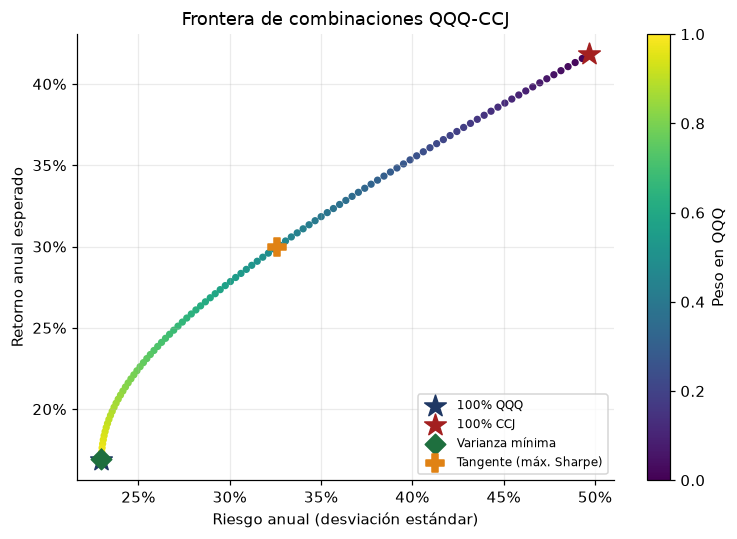

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(front["riesgo"], front["retorno"], c=front["w_QQQ"], cmap="viridis", s=14)
ax.scatter([np.sqrt(var_q)], [mu_a["QQQ"]], marker="*", s=220, color="#1f3864", label="100% QQQ", zorder=5)
ax.scatter([np.sqrt(var_c)], [mu_a["CCJ"]], marker="*", s=220, color="#a32020", label="100% CCJ", zorder=5)
ax.scatter([sd_minvar], [ret_minvar], marker="D", s=90, color="#1e6f3e", label="Varianza mínima", zorder=5)
ax.scatter([sd_tan], [ret_tan], marker="P", s=140, color="#e08214", label="Tangente (máx. Sharpe)", zorder=5)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("Riesgo anual (desviación estándar)")
ax.set_ylabel("Retorno anual esperado")
ax.set_title("Frontera de combinaciones QQQ-CCJ")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Peso en QQQ")
ax.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

**Decisión y justificación.**

- **CCJ sola** tuvo el mayor retorno histórico (~34% anual geométrico) y también el mayor Sharpe individual (0.76), superior al de QQQ (0.56): en estos 5 años, el riesgo adicional de CCJ sí fue remunerado con creces. Aun así, sigue siendo una **apuesta concentrada** en una sola empresa y un solo commodity: expuesta al precio del uranio, a contratos de suministro nuclear y a riesgo geopolítico/regulatorio del sector — riesgo específico que no está garantizado que el mercado siga remunerando hacia adelante de la misma forma en que lo hizo en este período retrospectivo.
- **QQQ solo** ofrece el retorno de mercado tecnológico de forma diversificada y de bajo costo, con menor riesgo absoluto (~23% anual), pero también menor retorno esperado, y su Sharpe (0.56) es el más bajo de las cuatro alternativas de la tabla.
- La **correlación moderada** (ρ≈0.46, punto 4) entre ambos activos implica que combinarlos genera beneficio de diversificación: la **cartera tangente** (≈47% QQQ / 53% CCJ) alcanza el **mayor Sharpe de las cuatro alternativas (≈0.80)**, superando tanto a QQQ solo (0.56) como a CCJ sola (0.76). El optimizador reparte el peso de forma casi equilibrada porque, aunque CCJ tiene mejor Sharpe individual, su correlación imperfecta con QQQ hace que añadir QQQ siga reduciendo el riesgo total de la cartera más de lo que resta retorno esperado.
- La **cartera de varianza mínima** (≈99.8% QQQ / 0.2% CCJ) muestra que, dado que la volatilidad de CCJ más que duplica la de QQQ, prácticamente no conviene añadir CCJ si el único objetivo es minimizar el riesgo total: casi toda la cartera de mínimo riesgo termina siendo QQQ.

**Recomendación:** para un inversionista que busca el mejor retorno ajustado por riesgo y puede tolerar la volatilidad adicional, la elección más razonable es **la combinación cercana a la cartera tangente (~45–50% QQQ / 50–55% CCJ)**, no un activo puro: captura el mejor balance riesgo-retorno observado en la muestra, usando la correlación imperfecta entre ambos para reducir el riesgo de la posición concentrada en CCJ. Un inversionista conservador, que priorice el riesgo absoluto sobre el Sharpe, debería quedarse esencialmente en QQQ (cartera de varianza mínima), añadiendo CCJ solo de forma marginal. Un inversionista con alta tolerancia al riesgo y convicción sobre la tesis nuclear/uranio podría justificar sobreponderar CCJ por encima del punto tangente, asumiendo conscientemente que la posición adicional es una apuesta de commodity/sector y no una posición diversificada.

## Notas y limitaciones

- **Fuente de datos:** Yahoo Finance, vía la librería `yfinance`, precios de cierre ajustados (dividendos y splits incorporados), frecuencia diaria.
- **Ventana:** 20-sep-2021 a 18-sep-2026 (1,254 retornos diarios), los 5 años exactos que pide el enunciado.
- **252 días bursátiles/año** es la convención estándar de mercado usada para anualizar medias y desviaciones estándar; asume retornos diarios i.i.d., supuesto razonable como aproximación pero no exacto (hay evidencia de autocorrelación y volatilidad agrupada — *volatility clustering* — en series financieras reales).
- Los resultados están fuertemente influenciados por el período específico analizado (un ciclo alcista para el uranio y para la tecnología): un desempeño histórico superior de CCJ no garantiza que su Sharpe siga siendo mayor que el de QQQ hacia adelante; esta es la limitación central de cualquier análisis basado enteramente en datos históricos.
- $r_f = 4\%$ anual es un supuesto de referencia para la razón de Sharpe del punto 5, no una serie observada de tasas; cambiar ese supuesto no altera los pesos de la cartera de varianza mínima, pero sí puede desplazar levemente los de la cartera tangente.